# Assignment 1: Classify Breast Cancer Cases

Author: Tobias Beekmans  
Master ICT – Software Engineering  
DataOps Specialisation Project – Individual Assignment  
Submission Date: 15.03.2026

**Short Description:**
The Breast Cancer dataset [1] is a widely used dataset for learning and practicing machine learning techniques. It contains diagnostic data for breast cancer cases, including features computed from digitized images of a fine needle aspirate (FNA) of a breast mass. These features describe characteristics of the cell nuclei, such as radius, texture, and smoothness, and are compiled into a convenient dataset.

**Goal:**
Develop a machine learning model to accurately classify breast cancer cases as malignant or benign.

In [3]:
# Data handling
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [4]:
data_dir = Path("../data/processed")

X_train = pd.read_csv(data_dir / "X_train_scaled.csv")
X_test = pd.read_csv(data_dir / "X_test_scaled.csv")

y_train = pd.read_csv(data_dir / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(data_dir / "y_test.csv").squeeze("columns")

# 5. Evaluation

In [5]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)

## 5.1 Evaluation Objectives

The purpose of the evaluation phase is to assess the performance of the trained models and determine which model is most suitable for the breast cancer classification task.

In a medical diagnostic context, evaluation metrics such as recall and false negative rates are particularly important, since incorrectly classifying malignant tumours as benign may delay necessary treatment.

Therefore, the evaluation focuses on confusion matrices, ROC curves, and overall classification performance.

## 5.2 Confusion Matrix

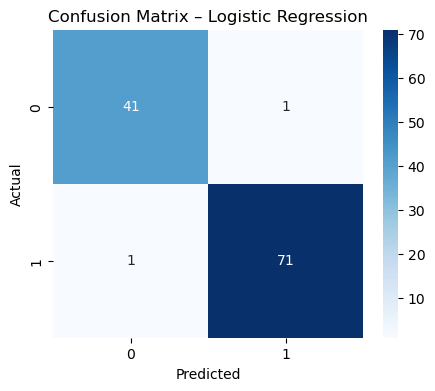

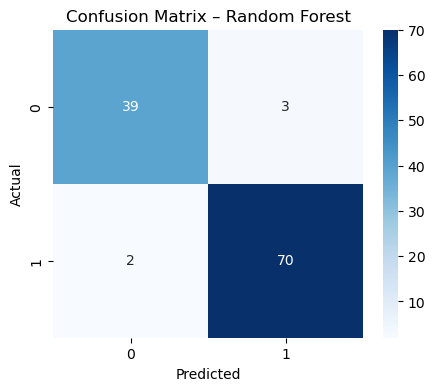

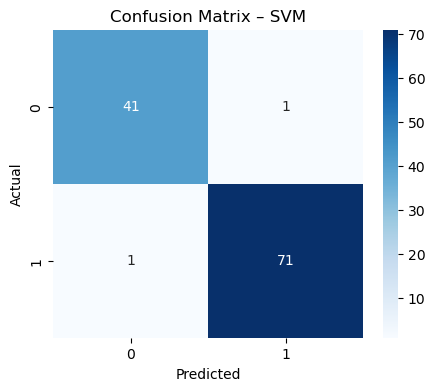

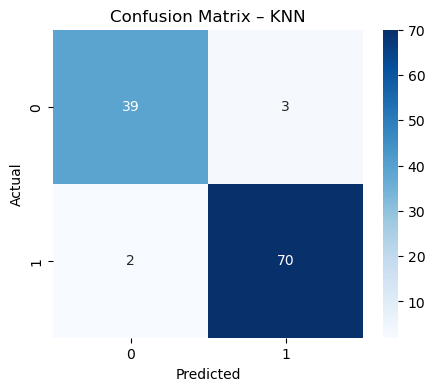

In [6]:
def plot_confusion_matrix(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    plt.show()

plot_confusion_matrix(y_test, y_pred_log, "Confusion Matrix – Logistic Regression")
plot_confusion_matrix(y_test, y_pred_rf, "Confusion Matrix – Random Forest")
plot_confusion_matrix(y_test, y_pred_svm, "Confusion Matrix – SVM")
plot_confusion_matrix(y_test, y_pred_knn, "Confusion Matrix – KNN")

## 5.3 ROC Curve and AUC

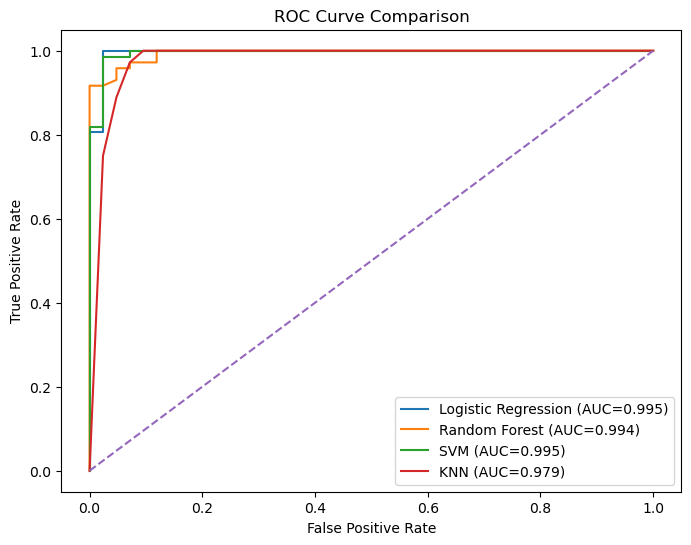

In [7]:
y_prob_log = log_model.predict_proba(X_test)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_prob_svm = svm_model.predict_proba(X_test)[:,1]
y_prob_knn = knn_model.predict_proba(X_test)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_knn = roc_auc_score(y_test, y_prob_knn)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc_svm:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.3f})")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

## 5.4 Model Comparison and Discussion

The evaluation results show that several models achieve very high classification performance on the dataset. Logistic Regression, Random Forest, and Support Vector Machine achieve nearly identical results, indicating that the classes are relatively well separable in the feature space.

K-Nearest Neighbours performs slightly worse, which may be due to the high dimensionality of the dataset. Distance-based methods can become less effective when many features are present.

## 5.5 Final Model Selection

Considering both predictive performance and model interpretability, Logistic Regression represents a suitable final model.

The model achieves high accuracy and recall while remaining relatively simple and interpretable compared to more complex models such as Random Forest or Support Vector Machines.